In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/User/Desktop/water/data/clean_water_stats.csv")
df = df.drop(columns=['Unnamed: 0'])
df = df.rename(columns= {'date_insert':'date'})
df['date'] = pd.to_datetime(df['date'])


In [4]:
metrics = [#'wtempV_°C',
 'conductivity_of_solution_ mS_cm',
 'oxidation_reduction_potential_ mV',
 'turbidity_NTU',
 'oxygen_saturation_%'
 ]

In [5]:
df[metrics].describe()

,conductivity_of_solution_ mS_cm,oxidation_reduction_potential_ mV,turbidity_NTU,oxygen_saturation_%
count,17957.000000,17957.000000,17957.000000,17957.000000
mean,51678.534029,144.677655,190.804007,64.578491
std,10266.878794,175.753262,151.633395,25.262752
min,6059.570000,-339.800000,0.000000,0.000000
25%,47649.910000,-2.150000,49.050000,50.210000
50%,55765.560000,188.890000,165.920000,64.200000
75%,58181.670000,297.940000,307.900000,82.340000
max,77197.730000,377.930000,499.930000,157.520000


#### Πινακες συσχετίσεων, ανα αισθητηρα

#### Ιστογραμματα 

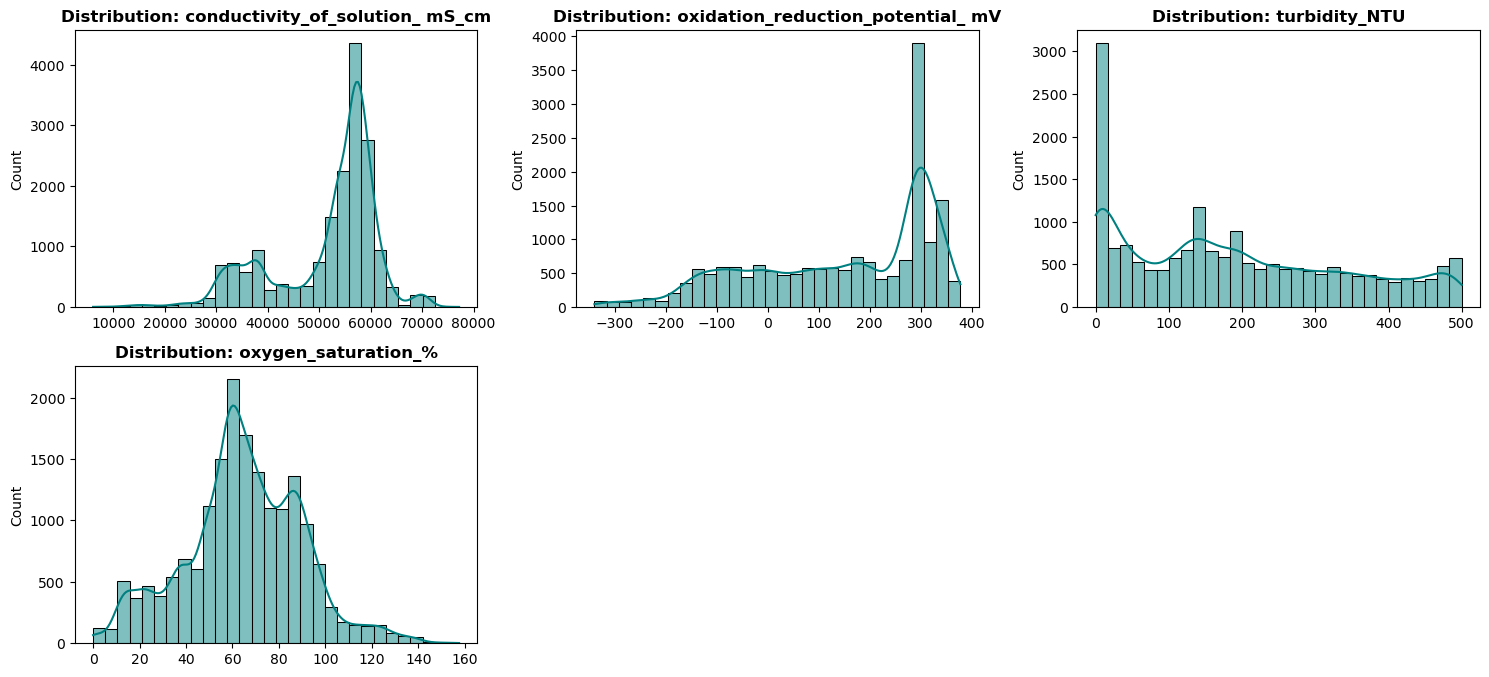

In [6]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(metrics, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='teal')
    plt.title(f'Distribution: {col}', fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### Πίνακες συσχετίσεων ανα αισθητήρα

C:\Users\User\AppData\Local\Temp\ipykernel_4616\3646932179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sensor_id', y=col, palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_4616\3646932179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sensor_id', y=col, palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_4616\3646932179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sensor_id', y=col, palette='Set2')
C:\Users\User\AppData\Local\Temp\ipykernel_4616\3646932179.py:4: FutureWa

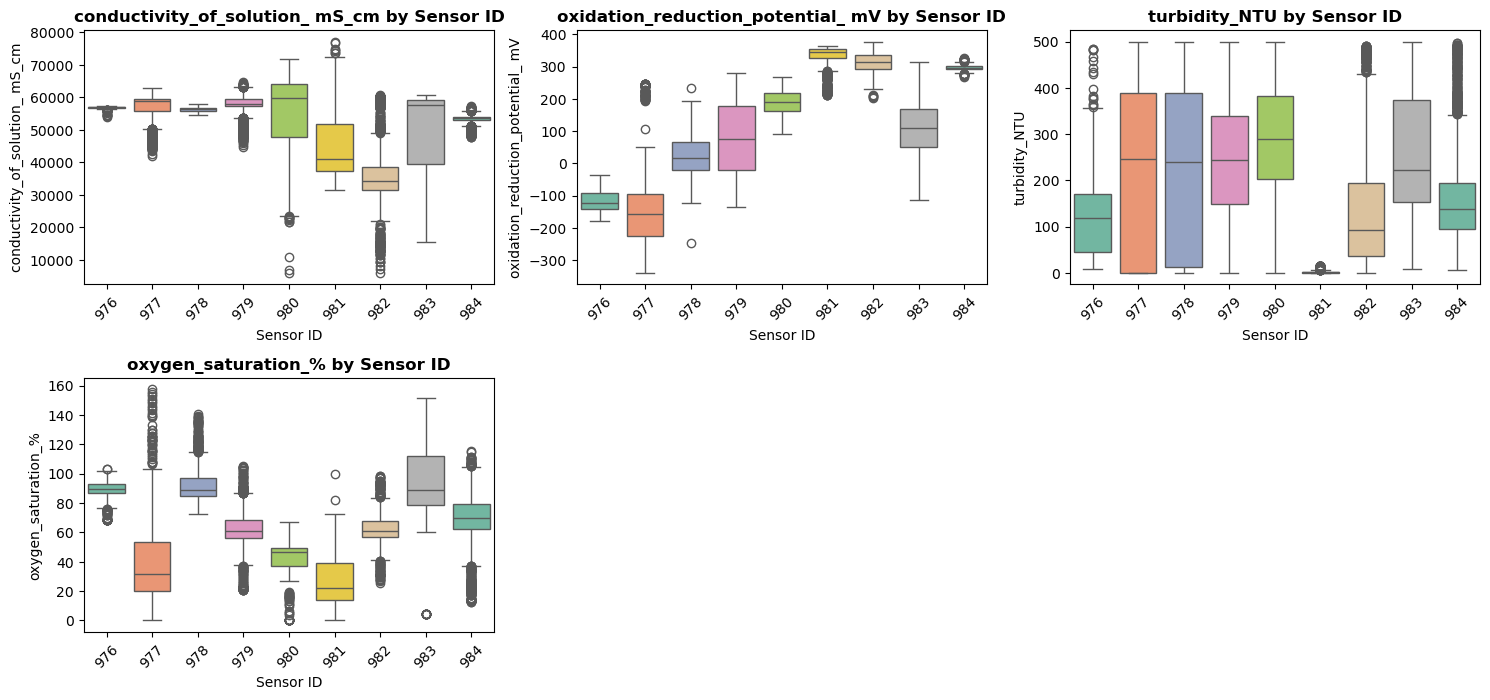

In [7]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(metrics, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='sensor_id', y=col, palette='Set2')
    plt.title(f'{col} by Sensor ID', fontweight='bold')
    plt.xlabel('Sensor ID')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

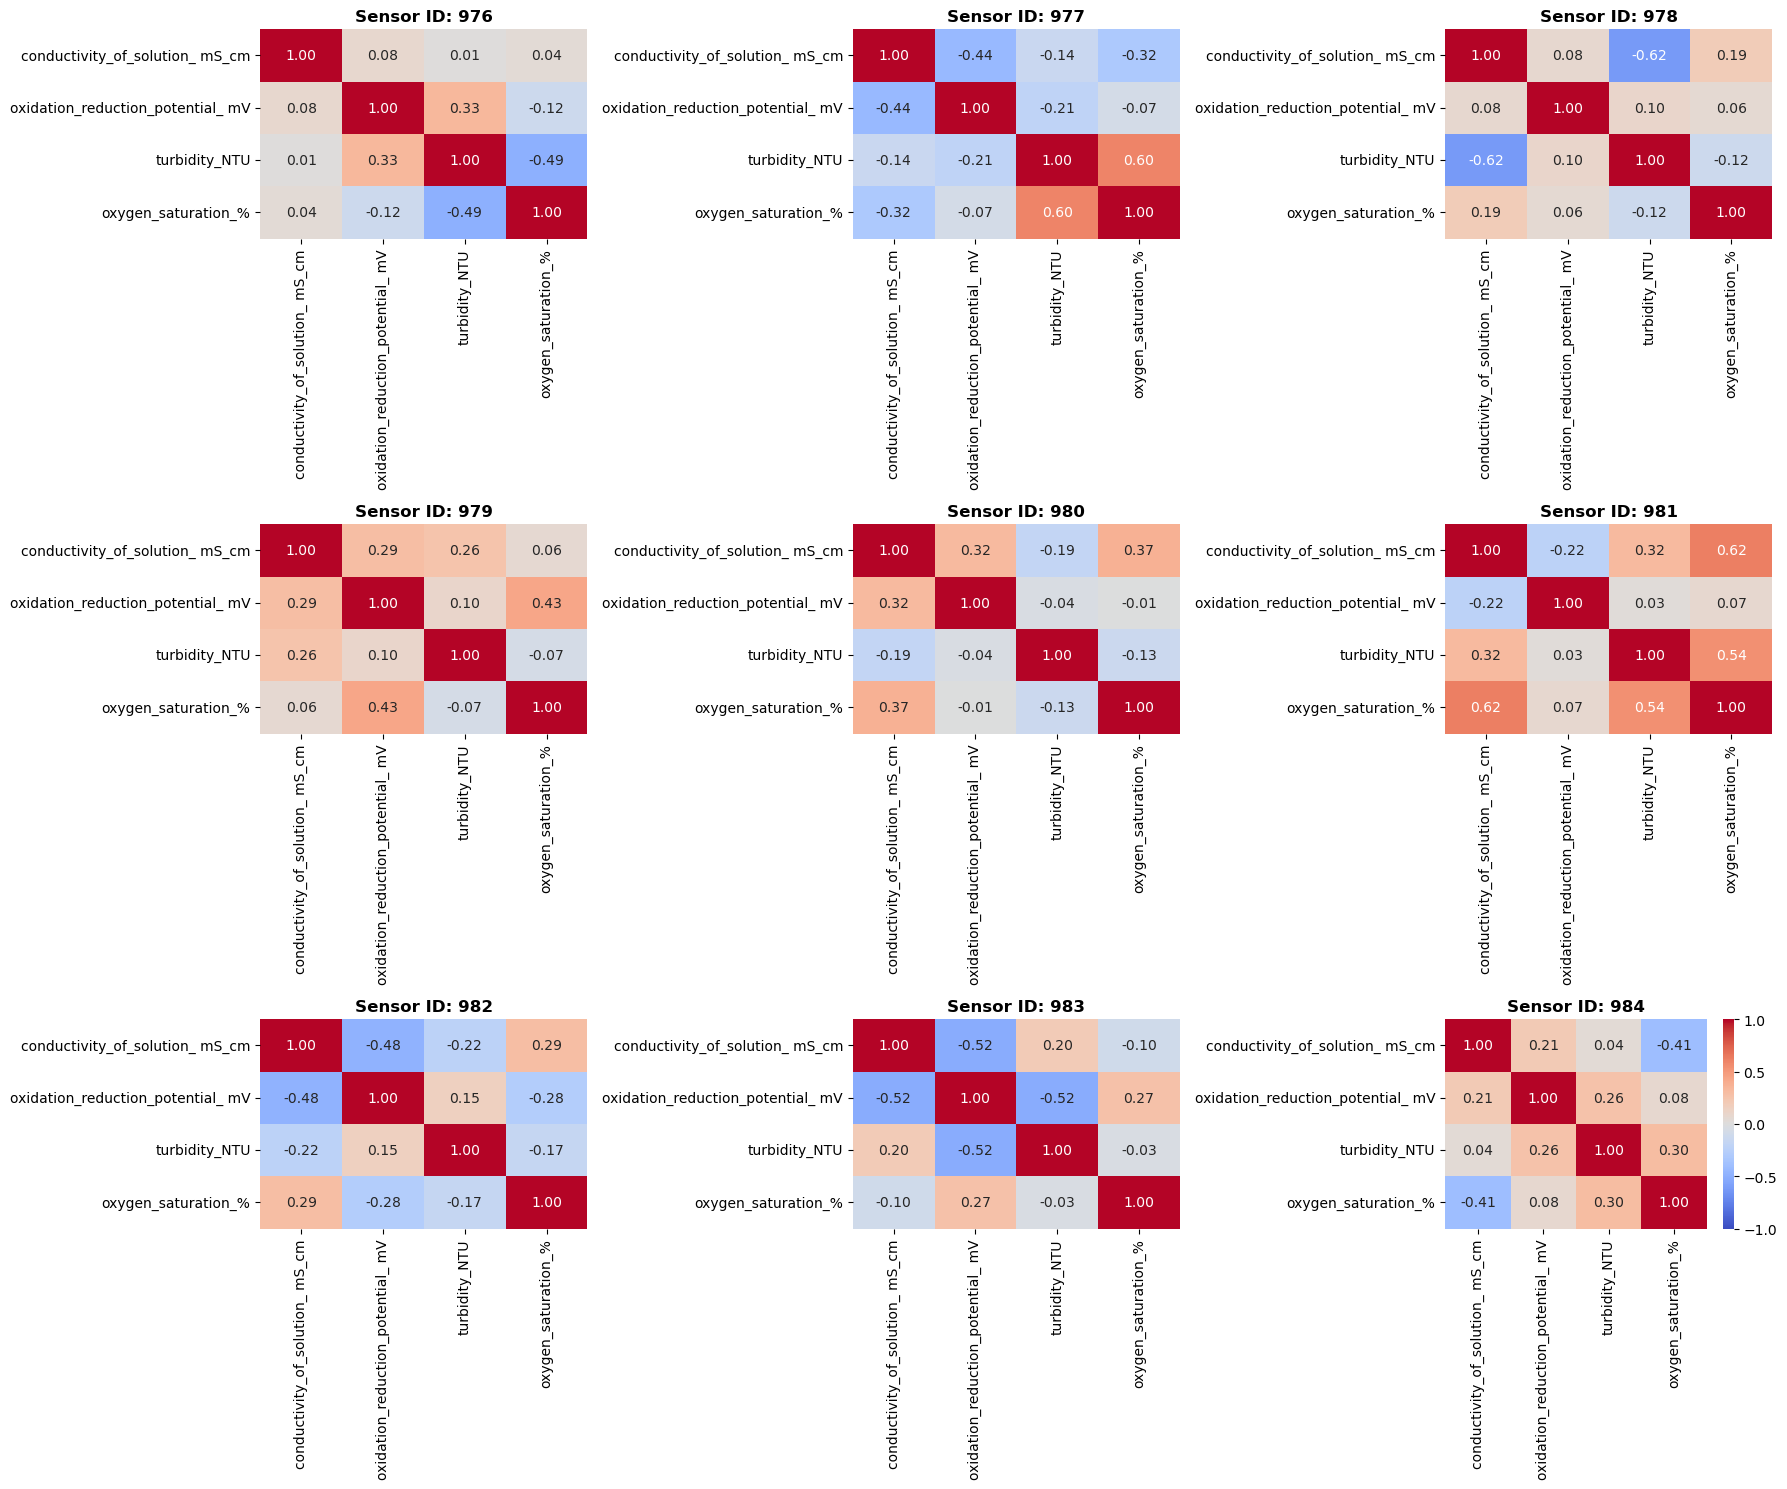

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Get unique sensor IDs
sensors = df['sensor_id'].unique()

for i, sensor_id in enumerate(sensors):
    sensor_df = df[df['sensor_id'] == sensor_id]
    corr = sensor_df[metrics].corr()
    
    sns.heatmap(
        corr, 
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1, 
        ax=axes[i],
        cbar=(i == 8) # Show colorbar only on the last plot to save space
    )
    axes[i].set_title(f'Sensor ID: {sensor_id}', fontweight='bold')

plt.tight_layout()
plt.show()